## Logistic Regression 

In [ ]:
import numpy as np

class MyLogisticRegression:
    def __init__(self, lr=0.01, n_iters=1000, reg_lambda=0):
        self.lr=lr
        self.n_iters=n_iters
        self.reg_lambda=reg_lambda
        
        self.weights=None
        self.bias=None
        
        self.loss_history=[]
        self.acc_history=[]
       
    # Sigmoid 
    def _sigmoid(self, z):
        return np.where(z>=0,
                        1/(1+np.exp(-z)),
                        np.exp(z)/(1+np.exp(z)))
        
    #Log Loss
    def _compute_loss(self, y, y_pred):
        epsilon=1e-15
        y_pred=np.clip(y_pred, epsilon, 1-epsilon)
        
        loss=-np.mean(y*np.log(y_pred)+(1-y)*np.log(1-y_pred))
        
        # Add L2 regularization
        reg_term=(self.reg_lambda/(2*len(y)))* np.sum(self.weights**2)
        
        return loss+reg_term
    
    # fit
    def fit(self, X, y):
        n_samples, n_features=X.shape
        
        self.weights=np.zeros(n_features)
        self.bias=0
        
        for _ in range(self.n_iters):
            linear_model=np.dot(X, self.weights)+self.bias
            y_pred=self._sigmoid(linear_model)
            
            # Gradients (with L2)
            dw=(1/n_samples)*np.dot(X.T, (y_pred-y))+(self.reg_lambda/n_samples)*self.weights
            db=(1/n_samples)*np.sum(y_pred-y)
            
            #Update
            self.weights-=self.lr*dw
            self.bias-=self.lr*db
            
            # Track loss and accuracy
            loss=self._compute_loss(y, y_pred)
            acc=np.mean((y_pred>=0.5)==y)
            
            self.loss_history.append(loss)
            self.acc_history.append(acc)
            
    # Predict probabilities
    def predict_proba(self, X):
        linear_model=np.dot(X, self.weights)+self.bias
        return self._sigmoid(linear_model)
    
    # Predict classes
    def predict(self, X):
        return (self.predict_proba(X)>=0.5).astype(int)
    
    # Accuracy
    def score(self, X, y):
        return np.mean(self.predict(X)==y)

    

## Metrics

In [ ]:
#### Confusion Matrix
def confusion_matrix(y_true, y_pred):
    tp=np.sum((y_true==1)&(y_pred==1))
    tn=np.sum((y_true==0) & (y_pred==0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return np.array([[tn, fp],
                     [fn, tp]])
    
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm):
    plt.imshow(cm)
    plt.title("Confusion Matrix")
    plt.xlabel("predicted")
    plt.ylabel("Actual")
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")
            
    plt.show()
     
    
##### Precision , Recall, F1 Score
def classification_metrics(y_true, y_pred):
    cm=confusion_matrix(y_true, y_pred)
    tn, fp=cm[0]
    fn, tp=cm[1]
    
    precision=tp/(tp+fp+1e-15)
    recall=tp/(tp+fn+1e-15)
    f1=2*(precision*recall)/(precision+recall+1e-15)
    
    return precision, recall, f1


#### ROC Curve
def roc_curve_manual(y_true, y_probs):
    thresholds=np.linspace(0, 1, 100)
    
    tprs=[]
    fprs=[]
    
    for t in thresholds:
        y_pred=(y_probs>=t).astype(int)
        cm=confusion_matrix(y_true, y_pred)
        
        tn, fp=cm[0]
        fn, tp=cm[1]
        
        tpr=tp/(tp+fn+1e-15)
        fpr=fp/(fp+tn+1e-15)
        
        tprs.append(tpr)
        fprs.append(fpr)
        
    return fprs, tprs

def plot_roc(fprs, tprs):
    plt.plot(fprs, tprs)
    plt.plot([0, 1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title('ROC Curve')
    plt.show()
    
    
def compute_auc(fprs, tprs):
    return np.trapezoid(tprs, fprs)

## Example Usage

In [5]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Data
data=load_breast_cancer()
X, y=data.data, data.target

# Split
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2
)

# Scale (VERY IMPORTANT)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train
model=MyLogisticRegression(lr=0.01, n_iters=1000)
model.fit(X_train, y_train)

# Predictions
y_probs=model.predict_proba(X_test)
y_pred=model.predict(X_test)

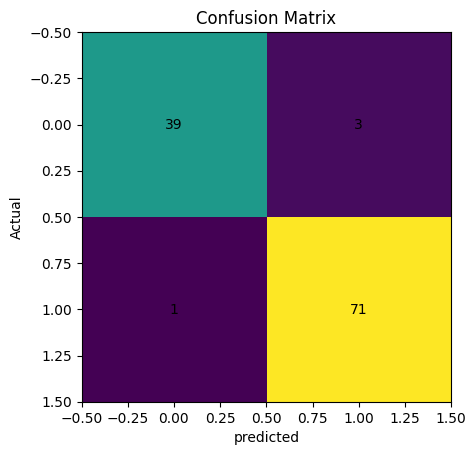

Precision: 0.9594594594594594
Recall: 0.9861111111111112
F1 Score: 0.9726027397260268


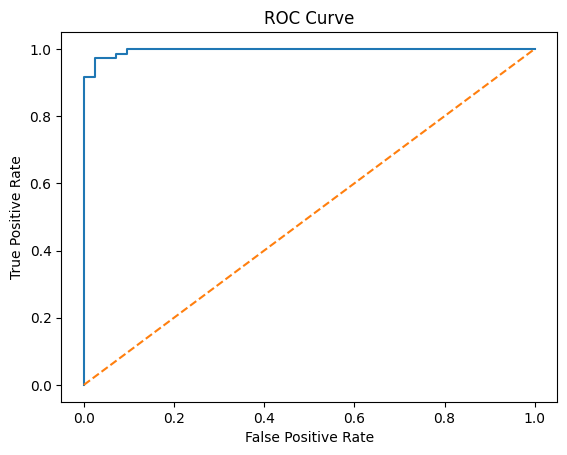

AUC: -0.996362433862434


In [6]:
########## Evaluate

#Confusion Matrix
cm=confusion_matrix(y_test, y_pred)
plot_confusion_matrix(cm)

#Metrics
precision, recall, f1=classification_metrics(y_test, y_pred)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# ROC + AUC
fprs, tprs=roc_curve_manual(y_test, y_probs)
plot_roc(fprs, tprs)

auc=compute_auc(fprs, tprs)
print("AUC:", auc)